In [1]:
import numpy as np
import keras
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
import sys
sys.path.append("../")


In [2]:
DATA_DIR = "../mu3e_trigger_data"
PLOTS_DIR = "../plots"
SIGNAL_DATA_FILE = f"{DATA_DIR}/sig_images.pkl"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/bg_images.pkl"
E5_DATA_FILE = f"{DATA_DIR}/e5_images.pkl"
FAMILONG_DATA_FILE = f"{DATA_DIR}/familong_images.pkl"
SIGNAL_ONLY_DATA_FILE = f"{DATA_DIR}/sig_only_images.pkl"

PHI_AXIS = 1
Z_AXIS = 2

In [3]:
def compute_hit_number(layer_list):
    return np.array([np.sum(layer, axis=(1, 2, 3)) for layer in layer_list]).sum(axis=0)

In [4]:
with open(SIGNAL_DATA_FILE, "rb") as f:
    signal_images = pickle.load(f)
with open(BACKGROUND_DATA_FILE, "rb") as f:
    background_images = pickle.load(f)
with open(E5_DATA_FILE, "rb") as f:
    e5_images = pickle.load(f)
with open(FAMILONG_DATA_FILE, "rb") as f:
    familong_images = pickle.load(f)
with open(SIGNAL_ONLY_DATA_FILE, "rb") as f:
    signal_only_images = pickle.load(f)

In [5]:
signal_hit_numbers = compute_hit_number(signal_images)
background_hit_numbers = compute_hit_number(background_images)
e5_hit_numbers = compute_hit_number(e5_images)
familong_hit_numbers = compute_hit_number(familong_images)
signal_only_hit_numbers = compute_hit_number(signal_only_images)

In [6]:
from sklearn.model_selection import train_test_split

layer_data = [
    np.concatenate([signal_images[i], background_images[i]], axis=0)
    for i in range(len(signal_images))
]
labels = [
    np.concatenate(
        [np.ones(signal_images[i].shape[0]), np.zeros(background_images[i].shape[0])],
        axis=0,
    )
    for i in range(len(signal_images))
]

train_data = []
train_labels = None
test_data = []
test_labels = None
for i in range(len(layer_data)):
    X_train, X_test, y_train, y_test = train_test_split(
        layer_data[i], labels[i], test_size=0.2, random_state=42
    )
    train_data.append(X_train)
    test_data.append(X_test)
    if train_labels is None:
        train_labels = y_train
    if test_labels is None:
        test_labels = y_test

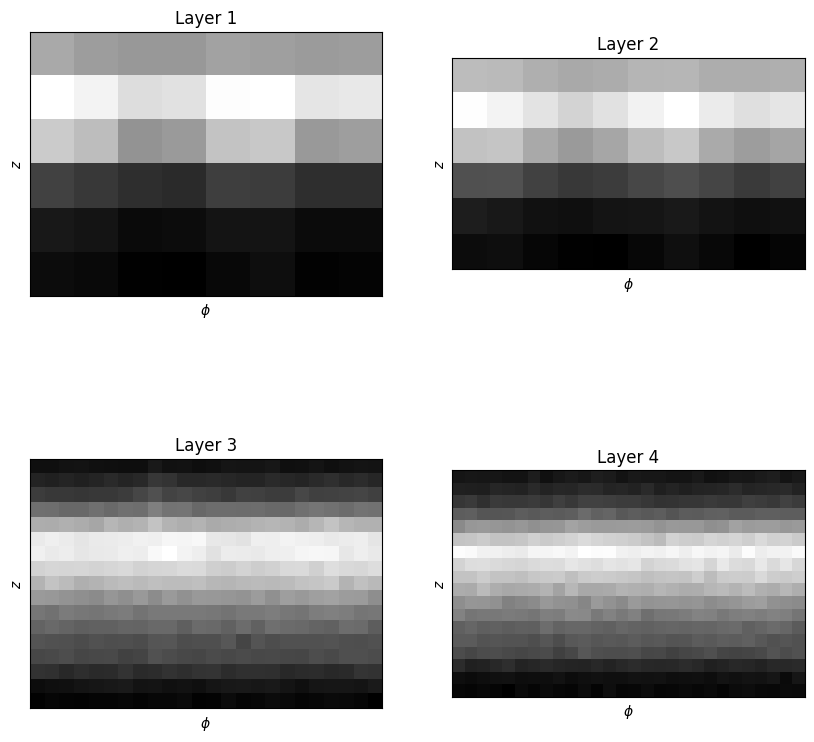

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for iter, layer in enumerate(signal_images):
    ax[iter // 2, iter % 2].imshow(layer.sum(axis=0).squeeze().T, cmap="gray")
    ax[iter // 2, iter % 2].set_title(f"Layer {iter+1}")
    ax[iter // 2, iter % 2].set_xticks([])
    ax[iter // 2, iter % 2].set_xlabel(r"$\phi$")
    ax[iter // 2, iter % 2].set_yticks([])
    ax[iter // 2, iter % 2].set_ylabel(r"$z$")

In [8]:
@keras.utils.register_keras_serializable(package="Custom")
class LearnableCylindricalResizer(keras.layers.Layer):
    """
    Resizes cylindrical detector layers to a common (phi, z) size
    with learnable interpolation, respecting periodicity in phi.
    """

    def __init__(self, target_phi, target_z, **kwargs):
        super().__init__(**kwargs)
        self.target_phi = target_phi
        self.target_z = target_z

    def build(self, input_shape):
        # input_shape: (batch, phi, z, channels)
        _, in_phi, in_z, channels = input_shape

        # Padding size in phi for circular padding
        self.phi_pad = (max(self.target_phi, in_phi) // 2) + 1

        # Learnable interpolation weights as Conv2D
        self.interp = keras.layers.Conv2D(
            filters=channels,
            kernel_size=(3, 3),
            padding='valid',   # we'll handle padding manually
            strides=(
                in_phi // self.target_phi if in_phi >= self.target_phi else 1,
                in_z // self.target_z if in_z >= self.target_z else 1
            ),
            groups=channels,   # per-channel learnable interpolation
            use_bias=True
        )

        super().build(input_shape)

    def call(self, inputs):
        # inputs: (batch, phi, z, channels)
        phi = tf.shape(inputs)[1]

        # Circular padding in phi
        left_pad = inputs[:, -self.phi_pad:, :, :]
        right_pad = inputs[:, :self.phi_pad, :, :]
        padded_phi = tf.concat([left_pad, inputs, right_pad], axis=1)

        # Zero padding in z (same style)
        padded = tf.pad(padded_phi, [[0,0],[0,0],[1,1],[0,0]])

        # Apply learnable interpolation conv
        x = self.interp(padded)

        # Resize to target (phi, z) with bilinear if mismatch remains
        x = tf.image.resize(x, (self.target_phi, self.target_z), method="bilinear")

        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "target_phi": self.target_phi,
            "target_z": self.target_z
        })
        return config


In [9]:
layer_shapes = [layer.shape[1:] for layer in signal_images]

In [10]:
layer_shapes

[(8, 6, 1), (10, 6, 1), (24, 17, 1), (28, 18, 1)]

In [11]:
layer_inputs = [keras.Input(shape=shape, name=f"input_layer_{layer_num + 1}") for layer_num, shape in enumerate(layer_shapes)]

In [12]:
target_phi=28; target_z=18

In [13]:
resized_layers = [
    LearnableCylindricalResizer(target_phi=target_phi, target_z=target_z,
                                name=f"resizer_layer_{layer_num + 1}")(layer_input)
    for layer_num, layer_input in enumerate(layer_inputs[:-1])
] + layer_inputs[-1:]

In [14]:
resized_layers

[<KerasTensor shape=(None, 28, 18, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>,
 <KerasTensor shape=(None, 28, 18, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>,
 <KerasTensor shape=(None, 28, 18, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>,
 <KerasTensor shape=(None, 28, 18, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_4>]

In [ ]:
from keras import layers

@keras.utils.register_keras_serializable(package="Custom")
class CylindricalConv3D(layers.Layer):
    """
    3D convolution with circular padding in phi and selectable padding in z and layer dimensions.
    """

    def __init__(
        self,
        filters,
        kernel_size,
        strides=(1, 1, 1),
        padding_z="same",
        padding_layer="same",
        activation=None,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size if isinstance(kernel_size, (tuple, list)) else (kernel_size,) * 3
        self.strides = strides
        self.padding_z = padding_z
        self.padding_layer = padding_layer
        self.activation = keras.activations.get(activation)

        # Conv3D layer; padding='valid' because we handle padding manually
        self.conv3d = layers.Conv3D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            strides=self.strides,
            padding="valid",
        )

    def pad_dim(self, x, dim, pad_size, mode):
        """Helper to pad a single dimension with various modes"""
        if mode == "same":
            pad = [[0, 0]] * len(x.shape)
            pad[dim] = [pad_size, pad_size]
            return tf.pad(x, pad)
        elif mode == "reflect":
            pad = [[0, 0]] * len(x.shape)
            pad[dim] = [pad_size, pad_size]
            return tf.pad(x, pad, mode="REFLECT")
        elif mode in ("replicate", "edge"):
            pad = [[0, 0]] * len(x.shape)
            pad[dim] = [pad_size, pad_size]
            return tf.pad(x, pad, mode="SYMMETRIC")
        elif mode == "valid":
            return x
        else:
            raise ValueError(f"Unsupported padding mode: {mode}")

    def call(self, inputs):
        # inputs shape: (batch, phi, z, layer, channels)
        phi_size = tf.shape(inputs)[1]

        # Circular padding in phi
        pad_phi = (self.kernel_size[0] -1 )// 2
        left_pad = inputs[:, -pad_phi:, :, :, :]
        right_pad = inputs[:, :pad_phi, :, :, :]
        x = tf.concat([left_pad, inputs, right_pad], axis=1)

        # Padding in z
        pad_z = (self.kernel_size[1] -1 )// 2
        x = self.pad_dim(x, dim=2, pad_size=pad_z, mode=self.padding_z)

        # Padding in layer dimension
        pad_layer = (self.kernel_size[2] -1 ) // 2
        x = self.pad_dim(x, dim=3, pad_size=pad_layer, mode=self.padding_layer)

        # Apply Conv3D
        x = self.conv3d(x)

        if self.activation is not None:
            x = self.activation(x)

        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "strides": self.strides,
            "padding_z": self.padding_z,
            "padding_layer": self.padding_layer,
            "activation": keras.activations.serialize(self.activation),
        })
        return config

from keras import layers

@keras.utils.register_keras_serializable(package="Custom")
class CrossLayerAttention(layers.Layer):
    """
    Applies multi-head attention across detector layers for each (phi, z) position.
    Input shape: (batch, phi, z, layer, channels)
    Output shape: same as input
    """

    def __init__(self, num_heads=4, key_dim=None, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim  # if None, defaults to channels // num_heads
        self.dropout = dropout

    def build(self, input_shape):
        _, phi, z, num_layers, channels = input_shape
        self.channels = channels
        if self.key_dim is None:
            self.key_dim = channels // self.num_heads

        # Multi-head attention layer
        self.mha = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.key_dim,
            dropout=self.dropout,
        )
        super().build(input_shape)

    def call(self, inputs, training=False):
        # inputs shape: (batch, phi, z, layer, channels)
        batch, phi, z, num_layers, channels = tf.unstack(tf.shape(inputs))

        # Flatten phi/z positions for attention
        x = tf.reshape(inputs, (batch * phi * z, num_layers, channels))  # (B*phi*z, L, C)

        # Self-attention across layers
        attn_out = self.mha(x, x, x, training=training) + x  # (B*phi*z, L, C)

        # Reshape back to original
        out = tf.reshape(attn_out, (batch, phi, z, num_layers, channels))
        return out

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "key_dim": self.key_dim,
            "dropout": self.dropout,
        })
        return config



@keras.utils.register_keras_serializable(package="Custom")
class CylindricalPooling3D(layers.Layer):
    """
    3D pooling with circular padding in phi and selectable padding in z and layer dimensions.
    """

    def __init__(
        self,
        pool_size=(2, 2, 2),
        strides=None,
        pooling_type="max",  # 'max' or 'avg'
        padding_z="same",
        padding_layer="same",
        **kwargs
    ):
        super().__init__(**kwargs)
        self.pool_size = pool_size if isinstance(pool_size, (tuple, list)) else (pool_size,) * 3
        self.strides = strides if strides is not None else self.pool_size
        self.pooling_type = pooling_type
        self.padding_z = padding_z
        self.padding_layer = padding_layer

        # Use pooling layers with padding='valid' because we handle padding manually
        if pooling_type == "max":
            self.pool = layers.MaxPooling3D(pool_size=self.pool_size, strides=self.strides, padding="valid")
        elif pooling_type == "avg":
            self.pool = layers.AveragePooling3D(pool_size=self.pool_size, strides=self.strides, padding="valid")
        else:
            raise ValueError(f"Unsupported pooling_type: {pooling_type}")

    def pad_dim(self, x, dim, pad_size, mode):
        """Helper to pad a single dimension with various modes."""
        if mode == "same":
            pad = [[0, 0]] * len(x.shape)
            pad[dim] = [pad_size, pad_size]
            return tf.pad(x, pad)
        elif mode == "reflect":
            pad = [[0, 0]] * len(x.shape)
            pad[dim] = [pad_size, pad_size]
            return tf.pad(x, pad, mode="REFLECT")
        elif mode in ("replicate", "edge"):
            pad = [[0, 0]] * len(x.shape)
            pad[dim] = [pad_size, pad_size]
            return tf.pad(x, pad, mode="SYMMETRIC")
        elif mode == "valid":
            return x
        else:
            raise ValueError(f"Unsupported padding mode: {mode}")

    def call(self, inputs):
        # inputs shape: (batch, phi, z, layer, channels)

        # Circular padding in phi
        pad_phi = self.pool_size[0] // 2
        left_pad = inputs[:, -pad_phi:, :, :, :]
        right_pad = inputs[:, :pad_phi, :, :, :]
        x = tf.concat([left_pad, inputs, right_pad], axis=1)

        # Padding in z
        pad_z = self.pool_size[1] // 2
        x = self.pad_dim(x, dim=2, pad_size=pad_z, mode=self.padding_z)

        # Padding in layer dimension
        pad_layer = self.pool_size[2] // 2
        x = self.pad_dim(x, dim=3, pad_size=pad_layer, mode=self.padding_layer)

        # Apply pooling
        return self.pool(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "pool_size": self.pool_size,
            "strides": self.strides,
            "pooling_type": self.pooling_type,
            "padding_z": self.padding_z,
            "padding_layer": self.padding_layer
        })
        return config

In [16]:
stacked_layers = keras.layers.Reshape(target_shape=(target_phi, target_z, 4,1))((keras.layers.Concatenate(axis=-1, name="stacked_layers")(resized_layers)))

In [ ]:
conv_1 = CylindricalConv3D(
    filters=8,
    kernel_size=(5, 5, 3),
    strides=(1, 1, 1),
    padding_z="valid",
    padding_layer="reflect",
    activation="relu",
    name="cylindrical_conv_1"
)(stacked_layers)
conv_attention = CrossLayerAttention(
    num_heads=4,
    key_dim=2,
    dropout=0.0,
    name="cross_layer_attention"
)(conv_1)
conv_2 = CylindricalConv3D(
    filters=16,
    kernel_size=(5, 5, 3),
    strides=(1, 1, 1),
    padding_z="valid",
    padding_layer="reflect",
    activation="relu",
    name="cylindrical_conv_2"
)(conv_attention)
conv_3 = CylindricalConv3D(
    filters=16,
    kernel_size=(5, 5, 3),
    strides=(1, 1, 1),
    padding_z="valid",
    padding_layer="valid",
    activation="relu",
    name="cylindrical_conv_3"
)(conv_2)
pool = layers.GlobalAveragePooling3D(name="global_average_pool")(conv_3)
from src.model.components import MLP
output = MLP(
    output_dim=1,
    num_layers=4,
    activation="sigmoid",
    name="mlp_output"
)(pool)

In [18]:
cnn_model = keras.Model(
    inputs=layer_inputs,
    outputs=output,
    name="CylindricalConv3DModel"
)

In [19]:
cnn_model.summary()

Model: "CylindricalConv3DModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 8, 6, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 10, 6, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 24, 17, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizer_layer_1     │ (None, 28, 18, 1) │         10 │ input_layer_1[0]… │
│ (LearnableCylindri… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizer_layer_2     │ (None, 28, 18, 1) │         10 │ input_layer_2[0]… │
│ (LearnableCylindri… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizer_layer_3     │ (None, 28, 18, 1) │         10 │ input_layer_3[0]… │
│ (LearnableCylindri… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, 28, 18, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stacked_layers      │ (None, 28, 18, 4) │          0 │ resizer_layer_1[… │
│ (Concatenate)       │                   │            │ resizer_layer_2[… │
│                     │                   │            │ resizer_layer_3[… │
│                     │                   │            │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 28, 18, 4, │          0 │ stacked_layers[0… │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cylindrical_conv_1  │ (None, 28, 14, 4, │        608 │ reshape[0][0]     │
│ (CylindricalConv3D) │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cylindrical_conv_2  │ (None, 28, 10, 4, │      9,616 │ cylindrical_conv… │
│ (CylindricalConv3D) │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cylindrical_conv_3  │ (None, 28, 6, 2,  │     19,216 │ cylindrical_conv… │
│ (CylindricalConv3D) │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_pool │ (None, 16)        │          0 │ cylindrical_conv… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_output (MLP)    │ (None, 1)         │        185 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 29,655 (115.84 KB)

 Trainable params: 29,655 (115.84 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy()]
)

In [21]:
cnn_model.predict([data[:10] for data in train_data])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


array([[0.5       ],
       [0.5       ],
       [0.5006491 ],
       [0.5002449 ],
       [0.50038207],
       [0.5       ],
       [0.50022095],
       [0.5       ],
       [0.50130665],
       [0.50062335]], dtype=float32)

In [22]:
cnn_model.fit(
    x=train_data,
    y=train_labels,
    validation_split=0.2,
    epochs=10,
    batch_size=512,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    ]
)

Epoch 1/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 342s 1s/step - binary_accuracy: 0.5846 - loss: 0.6845 - val_binary_accuracy: 0.6117 - val_loss: 0.6811
Epoch 2/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - binary_accuracy: 0.6163 - loss: 0.6794 - val_binary_accuracy: 0.6160 - val_loss: 0.6781
Epoch 3/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - binary_accuracy: 0.6190 - loss: 0.6765 - val_binary_accuracy: 0.6176 - val_loss: 0.6758
Epoch 4/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 301s 1s/step - binary_accuracy: 0.6223 - loss: 0.6742 - val_binary_accuracy: 0.6195 - val_loss: 0.6732
Epoch 5/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - binary_accuracy: 0.6250 - loss: 0.6717 - val_binary_accuracy: 0.6209 - val_loss: 0.6713
Epoch 6/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - binary_accuracy: 0.6281 - loss: 0.6692 - val_binary_accuracy: 0.6234 - val_loss: 0.6688
Epoch 7/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 300s 1s/step - binary_accuracy: 0.6292 - loss: 0.6672 - val_binary_accuracy: 0.6248 - val_loss: 0.6666

1143/1143 ━━━━━━━━━━━━━━━━━━━━ 28s 24ms/step


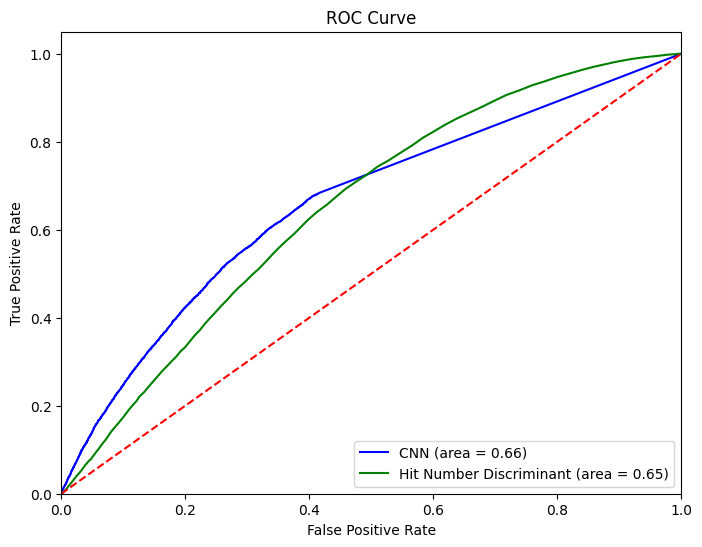

In [23]:
from sklearn.metrics import roc_curve, auc

y_pred_test = cnn_model.predict(test_data)
test_num_hits = compute_hit_number(test_data)
fpr, tpr, thresholds = roc_curve(test_labels, y_pred_test)
fpr_num_hit, tpr_num_hit, thresholds_num_hit = roc_curve(
    test_labels,
    test_num_hits,
)
roc_auc = auc(fpr, tpr)
roc_auc_num_hit = auc(fpr_num_hit, tpr_num_hit)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", label="CNN (area = {:.2f})".format(roc_auc))
plt.plot(
    fpr_num_hit,
    tpr_num_hit,
    color="green",
    label="Hit Number Discriminant (area = {:.2f})".format(roc_auc_num_hit),
)
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.savefig(PLOTS_DIR + "/cnn_roc_curve.png")

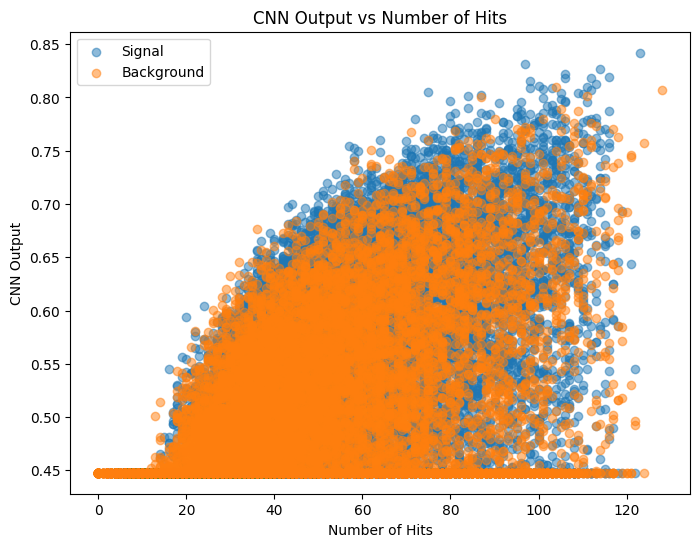

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    test_num_hits[test_labels == 1],
    y_pred_test[test_labels == 1],
    label="Signal",
    alpha=0.5,
)
ax.scatter(
    test_num_hits[test_labels == 0],
    y_pred_test[test_labels == 0],
    label="Background",
    alpha=0.5,
)
ax.set_xlabel("Number of Hits")
ax.set_ylabel("CNN Output")
ax.set_title("CNN Output vs Number of Hits")
ax.legend()
plt.savefig(PLOTS_DIR + "/cnn_output_vs_hits.png")